In [2]:
# import geobr
# gdf = geobr.read_municipality(code_muni='SP', year=2020)
# sp = gdf[gdf['name_muni'] == 'São Paulo']
# sp.crs= 'EPSG:4326'
# sp.explore(
#     tooltip = 'name_muni',
#     color = '#F6A429',
#     highlight_kwds={
#         'fillOpacity': 0.25
#         },
#     name = 'São Paulo',
#     tiles = 'CartoDB positron'
# )

In [3]:
##Transformar Excel em Dataframe e depois em GeoDataframe
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# 1. Carregar o Excel como DataFrame
df = pd.read_excel('Geral.xlsx', sheet_name='Tabela Geral')
df['lon'] = pd.to_numeric(df['Coordenada X'], errors='coerce')
df['lat'] = pd.to_numeric(df['Coordenada Y'], errors='coerce')
df.drop(columns=['Coordenada X', 'Coordenada Y'], inplace=True)
df = df.dropna(subset=['lon', 'lat'])

# 2. Criar a coluna de geometria com shapely Point (lon, lat)
geometry = [Point(xy) for xy in zip(df["lon"], df["lat"])]

# 3. Converter para GeoDataFrame
pontos = gpd.GeoDataFrame(df, geometry=geometry)

# 4. Definir o sistema de referência espacial (CRS)
pontos.set_crs(epsg=4326, inplace=True)

# 5. Visualizar
print(pontos.head())


      Ano Nota Empenho Nota Reserva    Ata CMDP  Processo SEI Unidade  \
0  2019.0   83174/2019   55487/2019  13/06/2019  6.012202e+15   SMSUB   
1  2019.0   83190/2019   55487/2019  13/06/2019  6.012202e+15   SMSUB   
2  2019.0   83190/2019   55487/2019  13/06/2019  6.012202e+15   SMSUB   
3  2019.0   83190/2019   55487/2019  13/06/2019  6.012202e+15   SMSUB   
4  2019.0   83192/2019   55487/2019  13/06/2019  6.012202e+15   SMSUB   

            Função                    Sub Função  \
0  26 - TRANSPORTE  451 - INFRA-ESTRUTURA URBANA   
1  26 - TRANSPORTE  451 - INFRA-ESTRUTURA URBANA   
2  26 - TRANSPORTE  451 - INFRA-ESTRUTURA URBANA   
3  26 - TRANSPORTE  451 - INFRA-ESTRUTURA URBANA   
4  26 - TRANSPORTE  451 - INFRA-ESTRUTURA URBANA   

                                         Programa  \
0  3009 - MELHORIA DA MOBILIDADE URBANA UNIVERSAL   
1  3009 - MELHORIA DA MOBILIDADE URBANA UNIVERSAL   
2  3009 - MELHORIA DA MOBILIDADE URBANA UNIVERSAL   
3  3009 - MELHORIA DA MOBILIDADE URB

In [4]:
pontos.explore()
#pontos.to_file("pontos.geojson", driver="GeoJSON")

In [5]:
# Caminho para o arquivo GeoJSON
caminho_arquivo = "subprefeituras.geojson"

# Carregar o GeoJSON como um GeoDataFrame
subpref = gpd.read_file(caminho_arquivo)

# Exibir as primeiras linhas
print(subpref.head())


   cd_identificador_subprefeitura cd_subprefeitura         nm_subprefeitura  \
0                             1.0               02         PIRITUBA-JARAGUA   
1                             2.0               03    FREGUESIA-BRASILANDIA   
2                             3.0               04  CASA VERDE-CACHOEIRINHA   
3                             4.0               05         SANTANA-TUCURUVI   
4                             5.0               06          JACANA-TREMEMBE   

  tx_escala sg_fonte_original dt_criacao  cd_tipo_discrepancia dt_atualizacao  \
0    1:5000            GEOGSG 2024-10-11             100200300     2024-10-11   
1    1:5000            GEOGSG 2024-10-11             100200300     2024-10-11   
2    1:5000            GEOGSG 2024-10-11             100200300     2024-10-11   
3    1:5000            GEOGSG 2024-10-11             100200300     2024-10-11   
4    1:5000            GEOGSG 2024-10-11             100200300     2024-10-11   

  cd_usuario_atualizacao sg_subprefeit

In [6]:
mix = gpd.read_file("mix.geojson")

# Exibir as primeiras linhas
print(mix.head())

DataSourceError: mix.geojson: No such file or directory

In [ ]:
mix.explore(
                color = 'red',
                weight = 1,
                label = 'nm_subprefeitura'
)

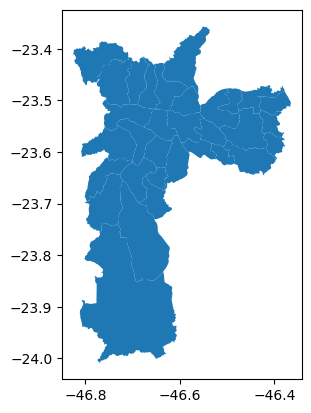

In [ ]:

import geopandas as gpd
import matplotlib.pyplot as plt

subs = gpd.read_file("subprefeituras.geojson")
subs.plot()
plt.show()


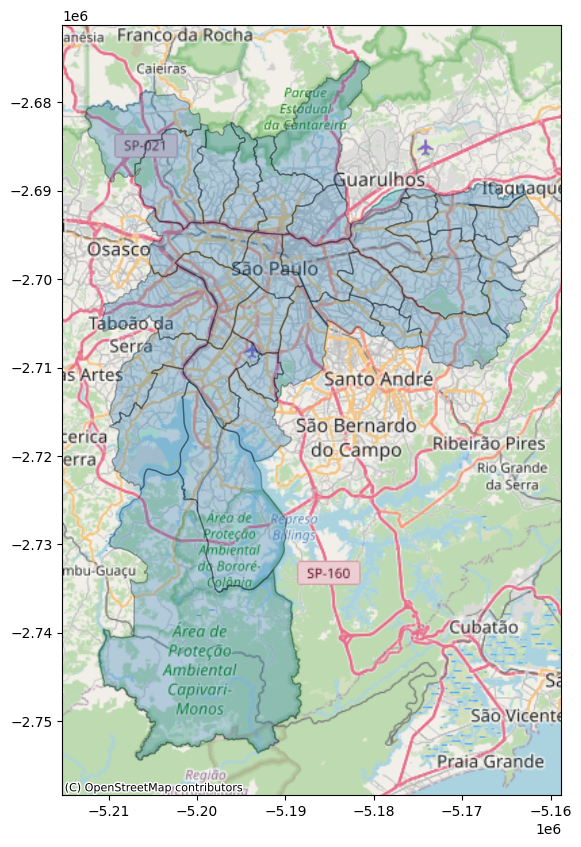

In [ ]:
import contextily as ctx

subs = subs.to_crs(epsg=3857)  # Projeção compatível com OSM
ax = subs.plot(figsize=(10, 10), alpha=0.3, edgecolor='k')
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
plt.show()


In [ ]:
# import matplotlib.pyplot as plt

# # Carregue seus arquivos (ajuste os caminhos conforme necessário)
# # subpref = gpd.read_file("caminho/para/subpref.shp")
# # pontos = gpd.read_file("caminho/para/pontos.shp")

# # Realize o spatial join para encontrar os pontos dentro das subprefeituras
# mix = gpd.sjoin(pontos, subpref, how="inner", predicate="intersects")

# # Plotagem
# fig, ax = plt.subplots(figsize=(10, 10))
# subpref.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.5, label='Subprefeituras')
# pontos.plot(ax=ax, color='gray', markersize=5, label='Todos os Pontos')
# mix.plot(ax=ax, color='red', markersize=10, label='Pontos Sobrepostos')

# plt.legend()
# plt.title("Pontos sobrepostos às Subprefeituras")
# plt.show()


In [ ]:
# import geopandas as gpd
# import folium
# from folium.plugins import MarkerCluster

# # Substitua pelos caminhos reais dos seus arquivos GeoJSON
# # subpref = gpd.read_file("CAMINHO_REAL/subpref.geojson")
# # pontos = gpd.read_file("CAMINHO_REAL/pontos.geojson")

# # Spatial join para identificar pontos sobrepostos
# mix = gpd.sjoin(pontos, subpref, how="inner", predicate="intersects")

# # Criar mapa base
# m = folium.Map(location=[subpref.geometry.centroid.y.mean(), subpref.geometry.centroid.x.mean()], zoom_start=12)

# # Adicionar subprefeituras
# folium.GeoJson(
#     subpref,
#     name="Subprefeituras",
#     style_function=lambda x: {
#         'color': 'black',
#         'weight': 1,
#         'fillColor': 'lightblue',
#         'fillOpacity': 0.5
#     }
# ).add_to(m)

# # Agrupar marcadores
# marker_cluster = MarkerCluster().add_to(m)

# # Adicionar todos os pontos
# for _, row in pontos.iterrows():
#     folium.Marker(
#         location=[row.geometry.y, row.geometry.x],
#         popup=folium.Popup(str(row.drop('geometry').to_dict()), max_width=300),
#         icon=folium.Icon(color='gray')
#     ).add_to(marker_cluster)

# # Adicionar pontos sobrepostos em vermelho
# for _, row in mix.iterrows():
#     folium.Marker(
#         location=[row.geometry.y, row.geometry.x],
#         popup=folium.Popup(str(row.drop('geometry').to_dict()), max_width=300),
#         icon=folium.Icon(color='red')
#     ).add_to(marker_cluster)

# # Adicionar controle de camadas
# folium.LayerControl().add_to(m)

# # Salvar o mapa
# m.save("mapa_interativo.html")
# print("Mapa salvo como mapa_interativo.html")


In [ ]:
fig = px.scatter_map(df, lat='lat', lon='lon', hover_name="Unidade", hover_data={'Ano': True, 'Nota Empenho': True, 'Nota Reserva': True, 'Ata CMDP': True, 'Processo SEI': True,
                                                                                                                'Função': True, 'Sub Função': True, 'Programa': True, 'Atividade': True,
                                                                                                                'Sub Elemento Despesa': True, 'Item Despesa': True, 'Observação Empenho':True,
                                                                                                                'Contrato': True, 'Credor Nome': True, 'Valor Empenho':True, 'Valor Empenho Cancelado':True,
                                                                                                                'Valor Empenho Líquido':True, 'Valor Empenho Liquidado':True,
                                                                                                                'Valor Empenho Pago':True, 'Equipamento 1': False, 'Equipamento 2': False, 'Endereço': True,
                                                                                                                'Região': True, 'Extensão (m)':False, 'Trecho (Recap)':False,
                                                                                                                'lat':False, 'lon':False}, 
                    size='Valor Empenho',
                    #size_max=15, size='Valor Empenho Pago', color='Valor Empenho', marker_size_max=150)
                    labels={'Valor Empenho': 'Valor Empenho (R$)'},              
                    center=dict(lat=-23.7, lon=-46.6), color_discrete_map={'15 - URBANISMO': 'blue','10 - SAÚDE': 'green','26 - TRANSPORTE': 'red','16 - HABITAÇÃO ': 'purple','08 - ASSISTÊNCIA SOCIAL': 'orange'}, color='Função', 
                    title="Análise de Empenho por Região",
                      zoom=10, height=900)
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

NameError: name 'px' is not defined